# Walkthroughs and Exercises for Statistical Modeling and Inference with

Python

Dr. Chester Ismay

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns
pd.set_option('display.max_columns', None)

# Turn off scientific notation
np.set_printoptions(suppress=True)
pd.options.display.float_format = '{:.10f}'.format

# Week 1

## Walkthrough 1.1: Getting Started

### Setting Up the Python Environment

If you haven’t already installed Python, Jupyter, and the necessary
packages, there are instructions on the course repo in the README to do
so
[here](https://github.com/ismayc/oreilly-fundamentals-of-statistics-with-python/blob/main/README.md).

If you aren’t able to do this on your machine, you may want to check out
[Google Colab](https://colab.research.google.com/). It’s a free service
that allows you to run Jupyter notebooks in the cloud.

In [ ]:
# Importing libraries/modules and aliasing them as needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import sklearn

### Load a dataset

In [ ]:
# Load in the dataset
spotify_sample = pd.read_csv("spotify_sample.csv")

### Prepare data

In [ ]:
# Select a single feature and target variable
X = spotify_sample[['acousticness']]
y = spotify_sample['energy']

### Create the model

In [ ]:
from sklearn.linear_model import LinearRegression

# Create and fit the model
model = LinearRegression()
model.fit(X, y)

LinearRegression()

Intercept: 0.7713193659794645

Accousticness coefficient: [-0.47021382]

### Make predictions

In [ ]:
# Store predicted values for each value of X
y_pred = model.predict(X)

# Define a new data point for prediction
new_data_point = pd.DataFrame({'acousticness': [0.35]})

# Make prediction
predicted_energy = model.predict(new_data_point)

print(f"Predicted energy for acousticness =",
      f"{new_data_point.iloc[0, 0]}: {round(predicted_energy[0], 2)}")

Predicted energy for acousticness = 0.35: 0.61

### Visualize the regression line

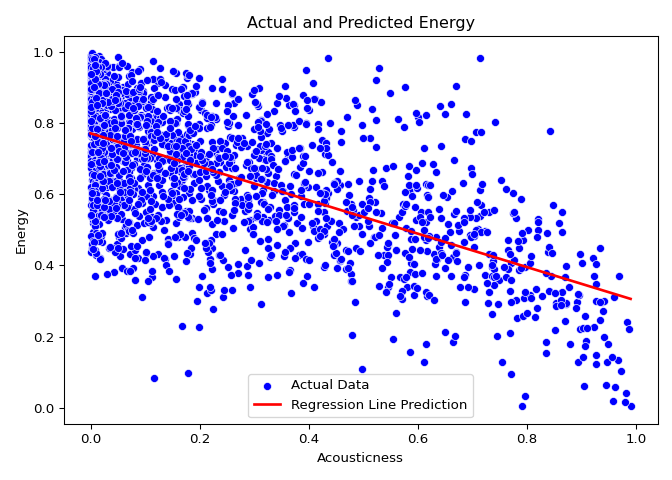

In [ ]:
# Plotting the results
sns.scatterplot(x=X.acousticness, y=y, color='blue', 
                label='Actual Data');
sns.lineplot(x=X.acousticness, y=y_pred, color='red', 
             label='Regression Line Prediction', linewidth=2);
plt.xlabel('Acousticness');
plt.ylabel('Energy');
plt.title('Actual and Predicted Energy');
plt.tight_layout();
plt.legend();
plt.show();

### Check if assumptions of linear regression met with visual tools

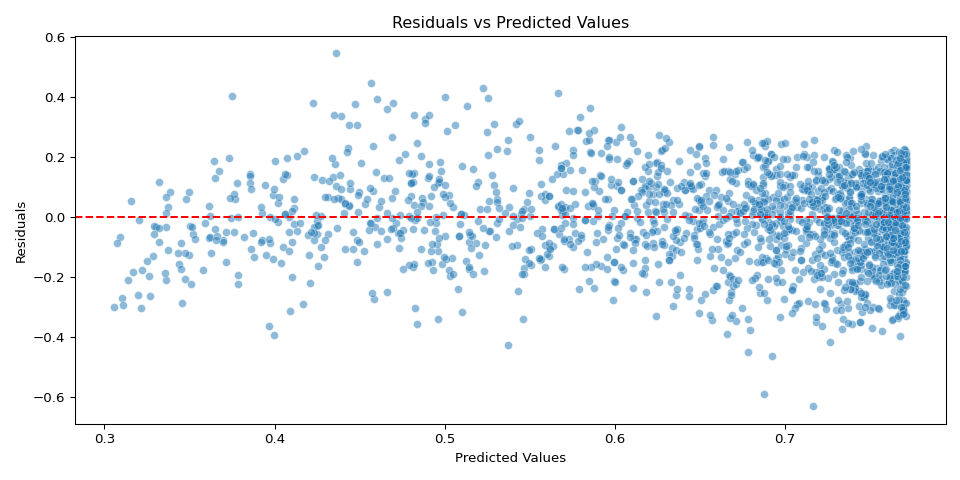

In [ ]:
# Check for Homoscedasticity
residuals = y - y_pred
plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.tight_layout()
plt.show();

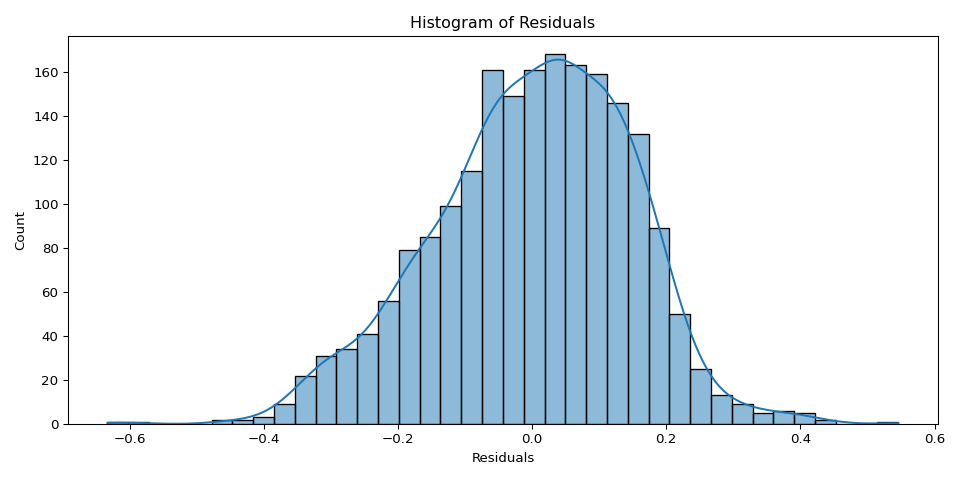

In [ ]:
# Check for Normality of Residuals
plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True)
plt.xlabel('Residuals')
plt.title('Histogram of Residuals')
plt.tight_layout()
plt.show();

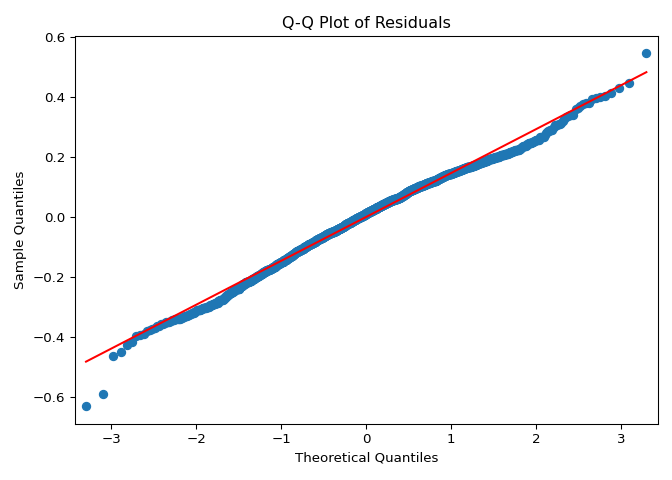

In [ ]:
sm.qqplot(residuals, line='s')
plt.title('Q-Q Plot of Residuals')
plt.tight_layout()
plt.show();

## Exercise 1.1: Getting Started

### Setting Up the Python Environment

If you ran the `# Importing libraries and aliasing them` code above, you
should be good to proceed here. If not, scroll up and run it.

### Load a dataset

In [ ]:
# Load in the dataset
imdb_movie_sample = pd.read_csv("imdb_movie_sample.csv")

### Prepare data

In [ ]:
# Select a single feature and target variable
X = imdb_movie_sample[['votes']]
y = imdb_movie_sample['rating']

### Create the model

In [ ]:
# Create and fit the model
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [ ]:
# Votes coefficient and intercept
print("Intercept:", model.intercept_)

Intercept: 6.031369821108833

Votes coefficient: [0.00000302]

### Make predictions

In [ ]:
# Store predicted values for each value of X
y_pred = model.predict(X)

In [ ]:
# Define a new data point for prediction (200,000 votes)
new_imdb_data = pd.DataFrame({'votes': [200_000]})

In [ ]:
# Make prediction
predicted_rating = model.predict(new_imdb_data)

In [ ]:
# Output results
print(f"Predicted rating for votes = ",
      f"{new_imdb_data.iloc[0, 0]}: {round(predicted_rating[0], 2)}")

Predicted rating for votes =  200000: 6.64

### Visualize the regression line

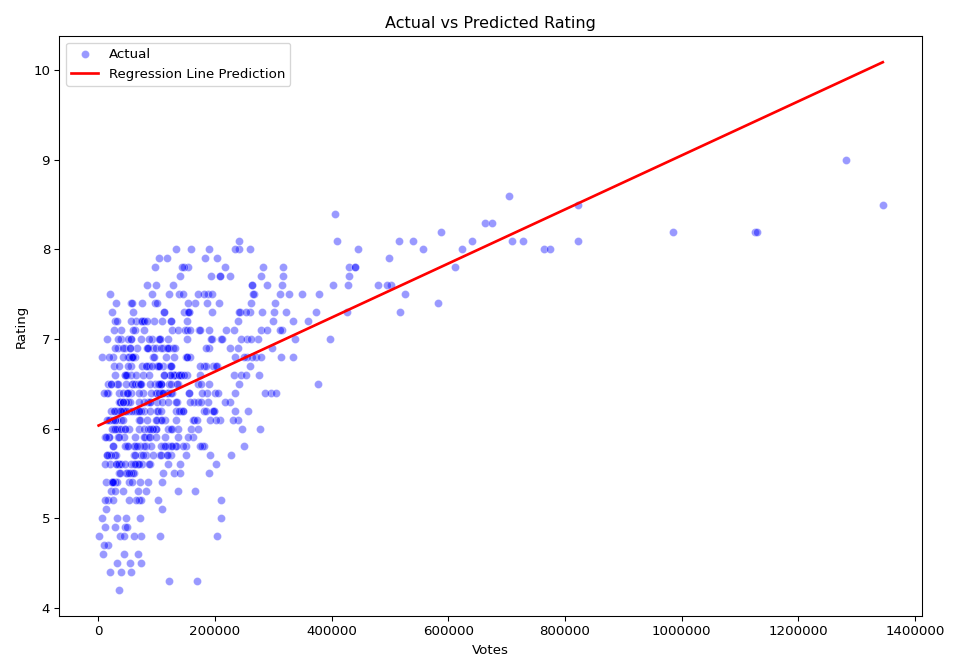

In [ ]:
# Plotting the results
plt.figure(figsize=(10, 7));
sns.scatterplot(x=X.votes, y=y, color='blue', label='Actual', alpha=0.4);
sns.lineplot(x=X.votes, y=y_pred, color='red', linewidth=2, label='Regression Line Prediction');
plt.xlabel('Votes');
plt.ylabel('Rating');
plt.title('Actual vs Predicted Rating');
 # Disable scientific notation on both axes
plt.ticklabel_format(style='plain', axis='both');
plt.legend();
plt.tight_layout()
plt.show();

### Check if assumptions of linear regression met with visual tools

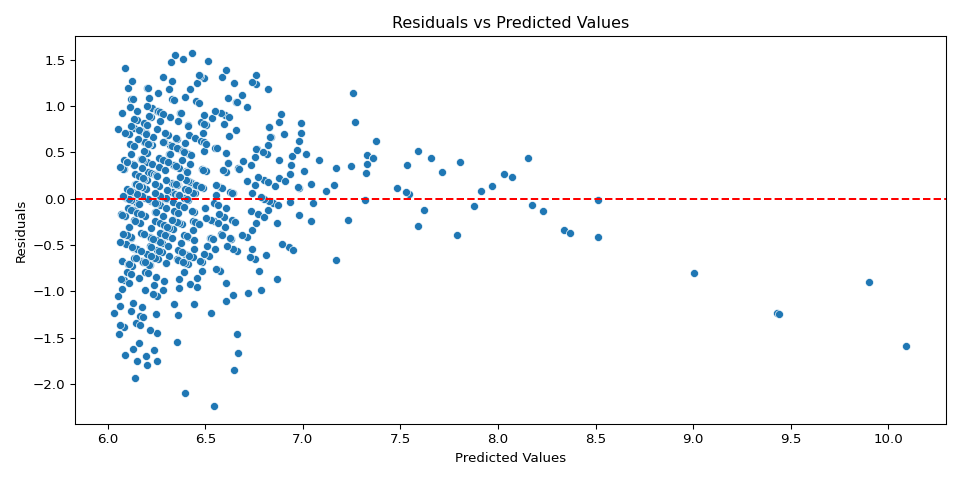

In [ ]:
# Check for Homoscedasticity
residuals = y - y_pred
plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.tight_layout()
plt.show();

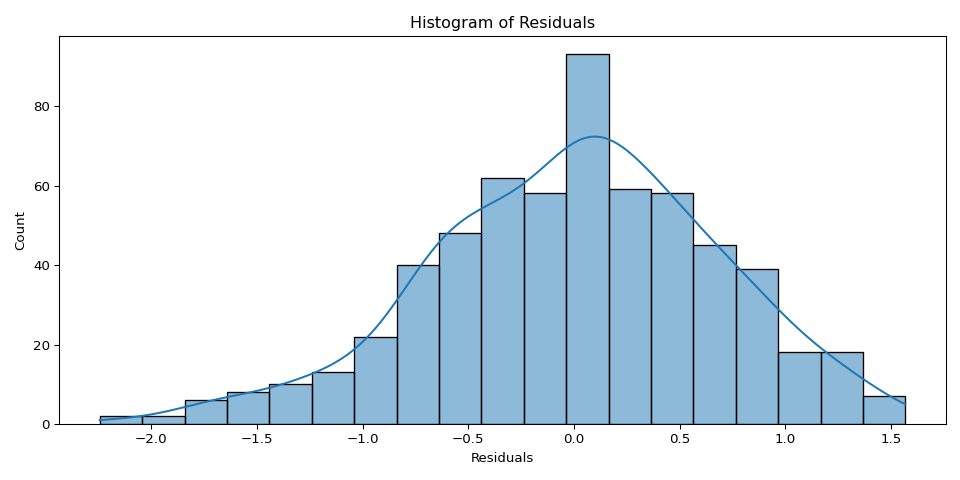

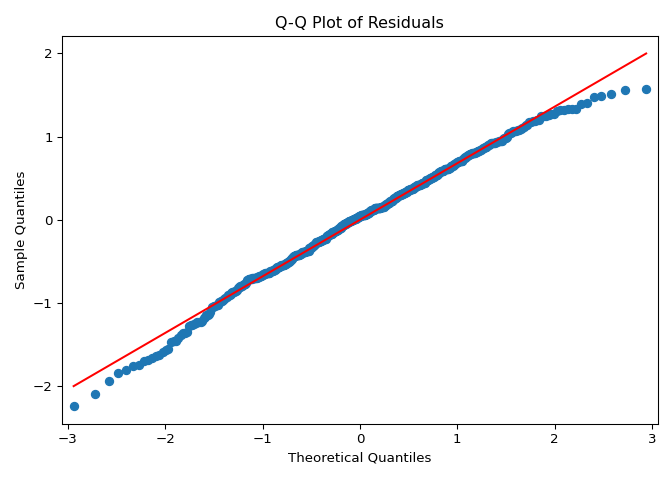

In [ ]:
# Check for Normality of Residuals
plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True)
plt.xlabel('Residuals')
plt.title('Histogram of Residuals')
plt.tight_layout()
plt.show();

## Walkthrough 1.2: Correlation

### Correlation matrix

In [ ]:
# Select only numeric columns
numeric_columns = spotify_sample.select_dtypes(include=[np.number])

# Calculate Pearson correlation matrix
correlation_matrix = numeric_columns.corr()

# Display the correlation matrix
correlation_matrix

                    popularity   duration_ms  danceability        energy  \
popularity        1.0000000000 -0.0822775509  0.1275317909  0.0100579962   
duration_ms      -0.0822775509  1.0000000000 -0.2647551344  0.0087408159   
danceability      0.1275317909 -0.2647551344  1.0000000000  0.0798122972   
energy            0.0100579962  0.0087408159  0.0798122972  1.0000000000   
key              -0.0276310408  0.0282827134  0.0325408526  0.0106713476   
loudness          0.0862158646 -0.0831994816  0.2227428691  0.7223389154   
mode             -0.0354825159  0.0471027863 -0.1286347155 -0.0828935271   
speechiness       0.0443355876 -0.1250772329  0.2295437431  0.1019747997   
acousticness     -0.0667138799 -0.0479062497 -0.0926857715 -0.6342350090   
instrumentalness -0.0561176175  0.0282486398 -0.1692649748 -0.1494373646   
liveness         -0.0089005983 -0.0153715439 -0.0648241906  0.1553282067   
valence          -0.0208077646 -0.1328668098  0.4184312450  0.3737440605   
tempo       

### Visualizing correlation matrix

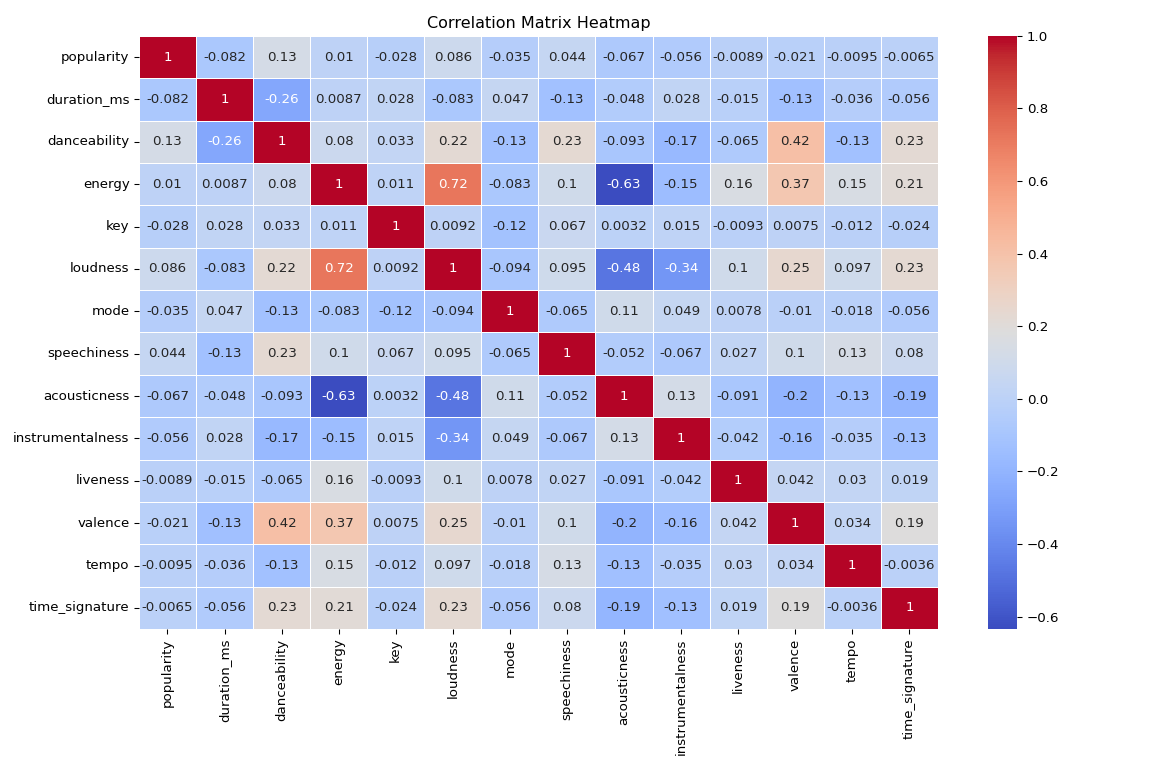

In [ ]:
# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show();

### Visualizing relationships

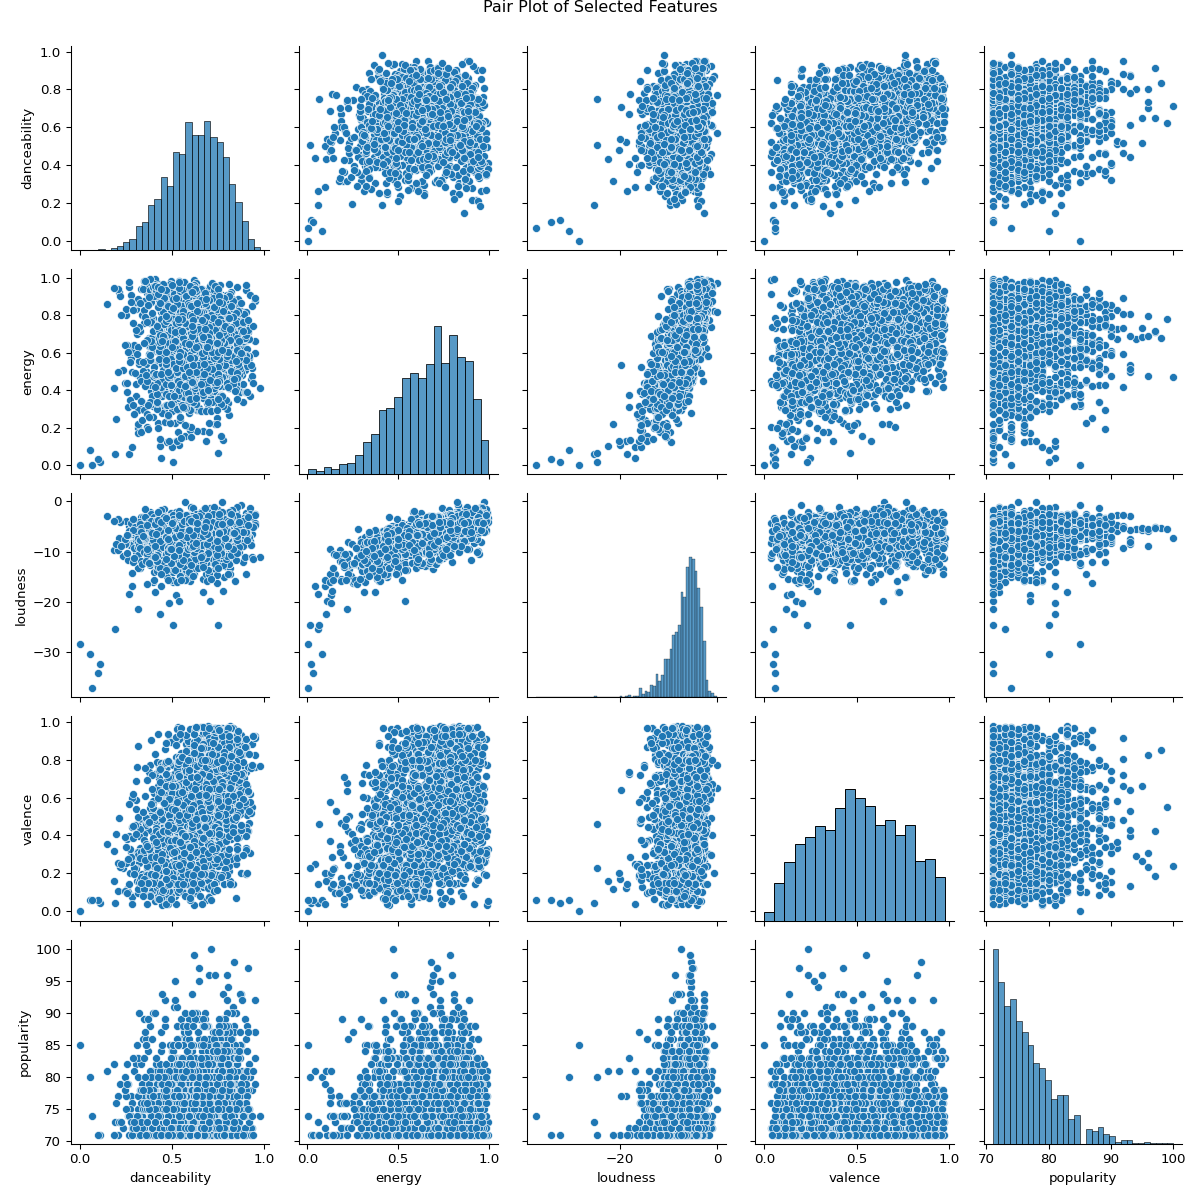

In [ ]:
# Plot pairplot to visualize relationships
sns.pairplot(
  numeric_columns[['danceability', 'energy', 'loudness', 
                   'valence', 'popularity']]
);
plt.suptitle('Pair Plot of Selected Features', y=1)
plt.tight_layout()
plt.show();

## Exercise 1.2: Correlation

### Correlation matrix

In [ ]:
# Select only numeric columns
numeric_columns = imdb_movie_sample.select_dtypes(include=[np.number])

# Calculate Pearson correlation matrix
correlation_matrix = numeric_columns.corr()

# Display the correlation matrix
correlation_matrix

                            year  runtime_in_minutes        rating  \
year                1.0000000000       -0.2200207410 -0.2256792958   
runtime_in_minutes -0.2200207410        1.0000000000  0.4538504288   
rating             -0.2256792958        0.4538504288  1.0000000000   
votes               0.0831128989        0.3055441794  0.5834591385   
gross_in_dollars    0.0085255389       -0.0039430790 -0.0499238169   

                          votes  gross_in_dollars  
year               0.0831128989      0.0085255389  
runtime_in_minutes 0.3055441794     -0.0039430790  
rating             0.5834591385     -0.0499238169  
votes              1.0000000000      0.0300793927  
gross_in_dollars   0.0300793927      1.0000000000  

## Visualizing correlation matrix

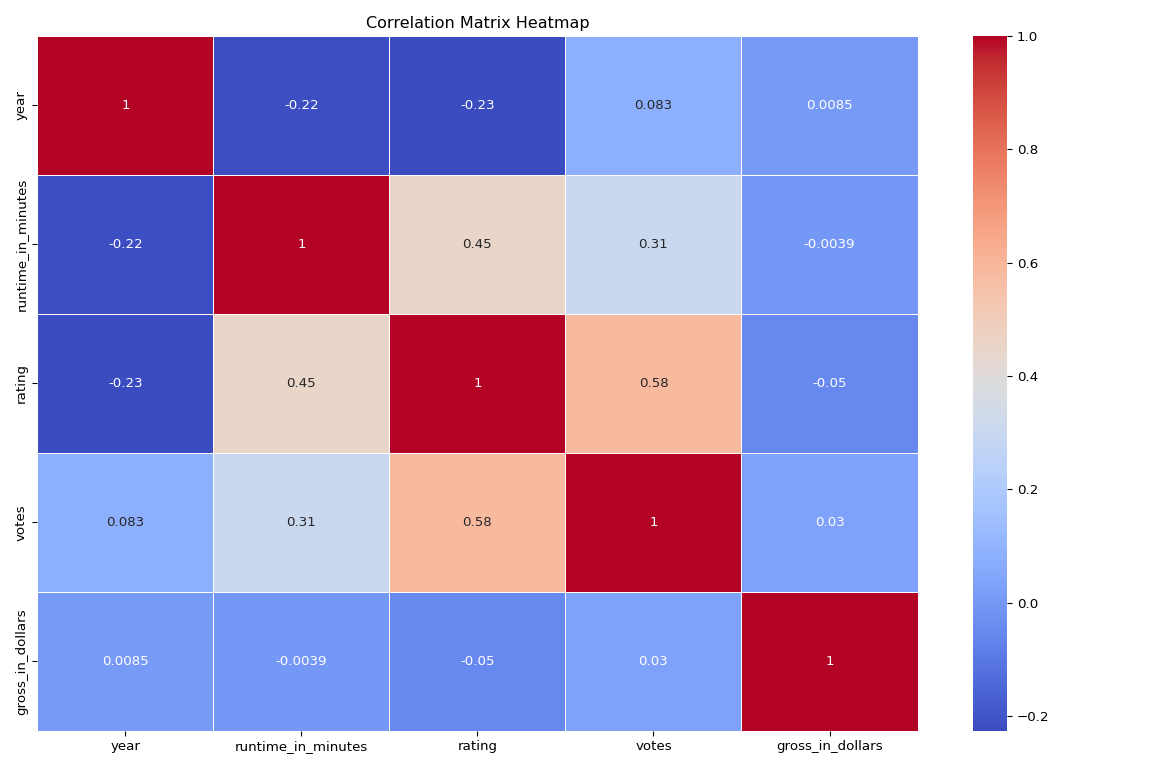

In [ ]:
# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

### Visualizing relationships

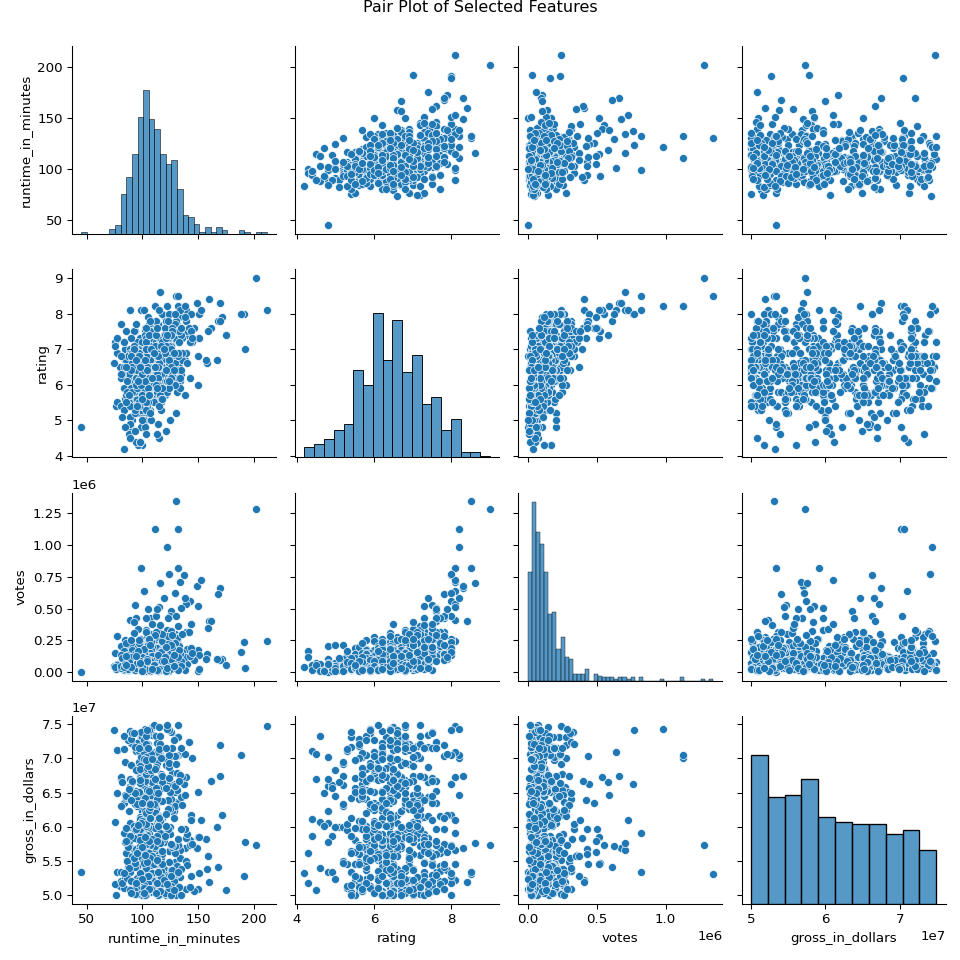

In [ ]:
# Plot pairplot to visualize relationships of 
# runtime_in_minutes, rating, votes, and gross_in_dollars
sns.pairplot(
  numeric_columns[['runtime_in_minutes', 'rating', 'votes', 'gross_in_dollars']]
);
plt.suptitle('Pair Plot of Selected Features', y=1)
plt.tight_layout()
plt.show();

## Walkthrough 1.3: Multiple Regression

In [ ]:
# Prepare the data for multiple regression by choosing 
# Predictors: danceability, energy, and loudness
# Response: popularity
X = spotify_sample[['danceability', 'energy', 'loudness']]
y = spotify_sample['popularity']

In [ ]:
# Fit the multiple regression model
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [ ]:
# Coefficients and intercept
print("Intercept:", model.intercept_)

Intercept: 77.17575701553045

Coefficients: [ 3.4069261  -2.350777    0.19138243]

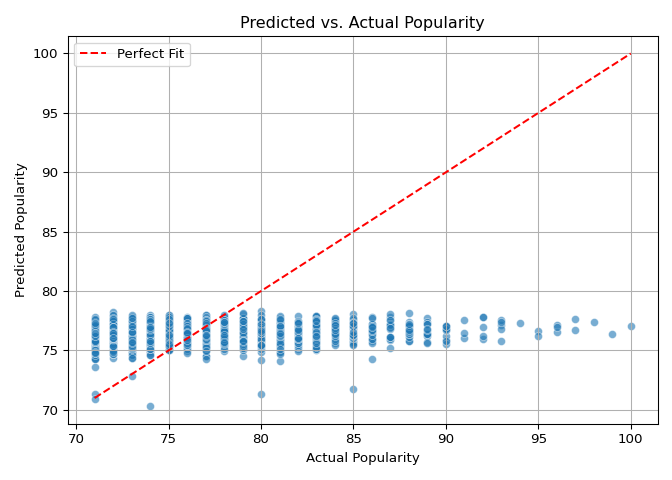

In [ ]:
# Plot predicted vs. actual
sns.scatterplot(x=y, y=y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', label='Perfect Fit')
plt.xlabel('Actual Popularity')
plt.ylabel('Predicted Popularity')
plt.title('Predicted vs. Actual Popularity')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Exercise 1.3: Multiple Regression

In [ ]:
# Prepare the data for multiple regression by choosing 
# Predictors: runtime_in_minutes, votes, and gross_in_dollars
# Response: rating
X = imdb_movie_sample[['runtime_in_minutes', 'votes', 'gross_in_dollars']]
y = imdb_movie_sample['rating']

In [ ]:
# Fit the model
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [ ]:
# Coefficients and intercept
print("Intercept:", model.intercept_)

Intercept: 5.07418203096002

Coefficients: [ 0.0133726   0.00000255 -0.00000001]

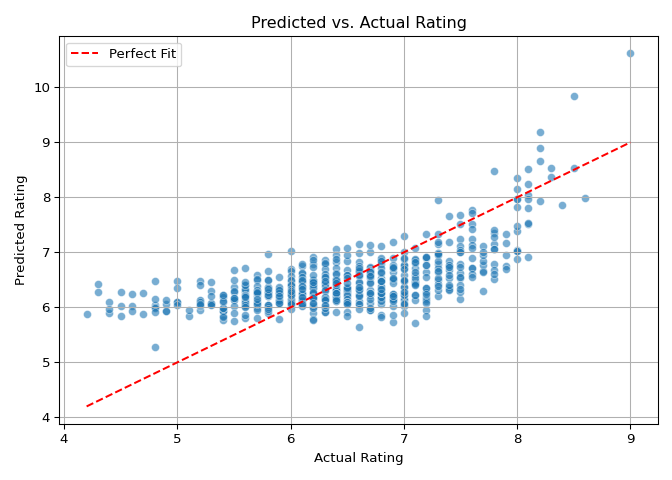

In [ ]:
# Plot predicted vs. actual
sns.scatterplot(x=y, y=y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', label='Perfect Fit')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Predicted vs. Actual Rating')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Walkthrough 1.4: Logistic Regression

### Logistic Regression with a Single Predictor

In [ ]:
from sklearn.linear_model import LogisticRegression

# Set loudness as predictor/feature and binarize energy: high energy = 1
X = spotify_sample[['loudness']]
y = (spotify_sample['energy'] > 0.6).astype(int)

In [ ]:
# Fit model
model = LogisticRegression()
model.fit(X, y)

LogisticRegression()

In [ ]:
# Predict over a smooth range
x_vals = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
probs = model.predict_proba(x_vals)[:, 1]

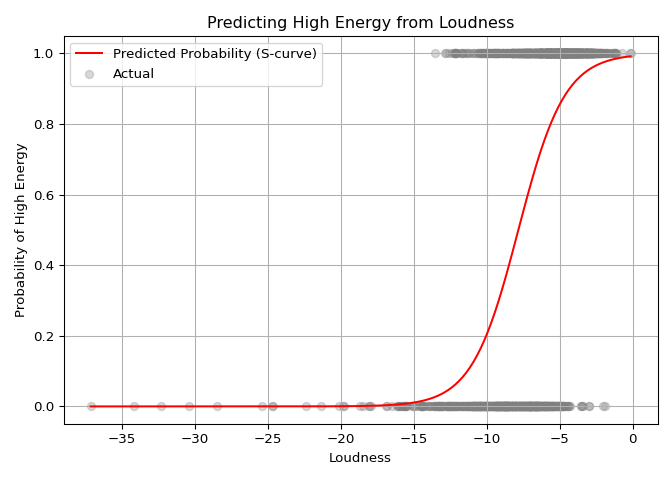

In [ ]:
# Plot predicted and actual energy against loudness
plt.plot(x_vals, probs, color='red', label='Predicted Probability (S-curve)')
plt.scatter(X, y, alpha=0.3, color='gray', label='Actual')
plt.title('Predicting High Energy from Loudness')
plt.xlabel('Loudness')
plt.ylabel('Probability of High Energy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Logistic Regression with Multiple Predictors

In [ ]:
# Define predictors (loudness and acousticness) and binary energy response
X = spotify_sample[['loudness', 'acousticness']]
y = (spotify_sample['energy'] > 0.6).astype(int)

In [ ]:
# Fit the logistic regression model
model = LogisticRegression()
model.fit(X, y)

LogisticRegression()

In [ ]:
# Predict probabilities
spotify_sample['predicted_prob'] = model.predict_proba(X)[:, 1]

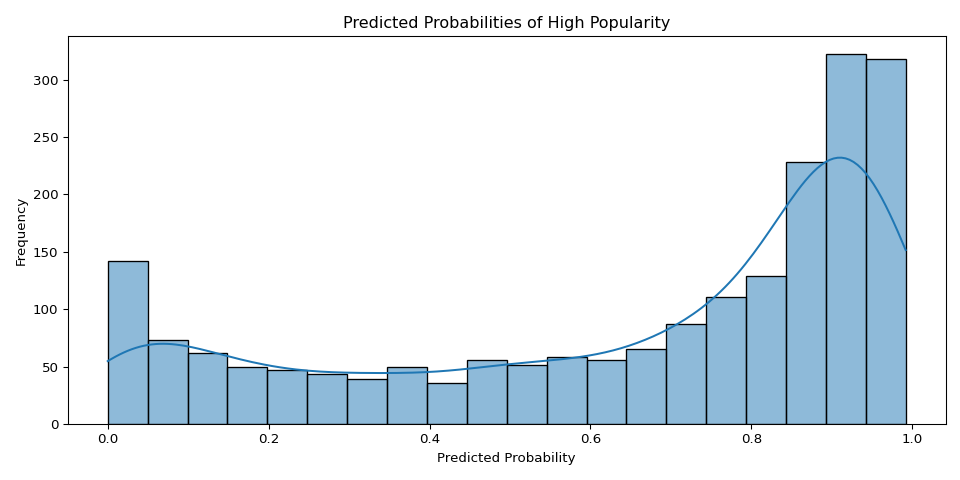

In [ ]:
# Plot the predicted probabilities
plt.figure(figsize=(10, 5))
sns.histplot(spotify_sample['predicted_prob'], bins=20, kde=True)
plt.title('Predicted Probabilities of High Popularity')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

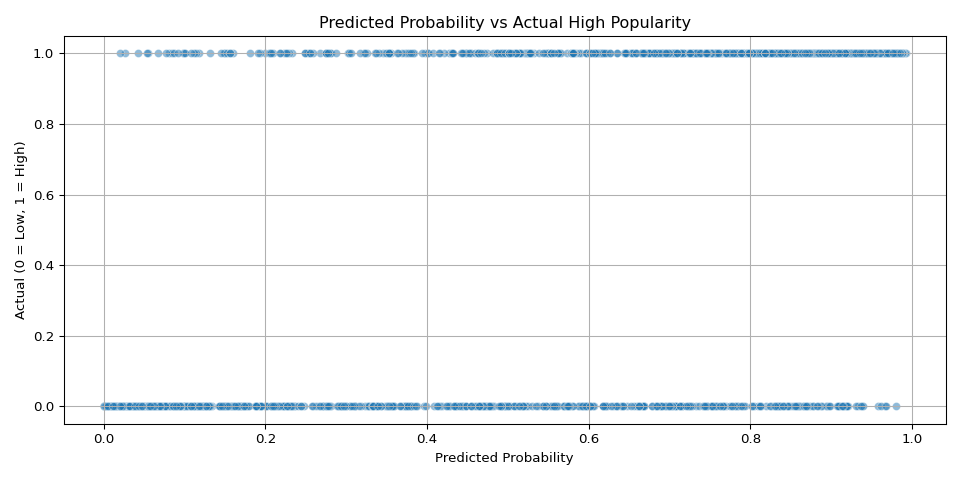

In [ ]:
# Scatter plot: predicted probability vs actual outcome
plt.figure(figsize=(10, 5))
sns.scatterplot(x=spotify_sample['predicted_prob'], y=y, alpha=0.5)
plt.title('Predicted Probability vs Actual High Popularity')
plt.xlabel('Predicted Probability')
plt.ylabel('Actual (0 = Low, 1 = High)')
plt.grid(True)
plt.tight_layout()
plt.show()

## Exercise 1.4: Logistic Regression

### Logistic Regression with a Single Predictor

In [ ]:
# Define votes predictor and 
# binary rating response (rating > 7 -> high rating)
X = imdb_movie_sample[['votes']]
y = (imdb_movie_sample['rating'] > 7).astype(int)

In [ ]:
# Fit model
model = LogisticRegression()
model.fit(X, y)

LogisticRegression()

In [ ]:
# Predict over a smooth range
x_vals = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
probs = model.predict_proba(x_vals)[:, 1]

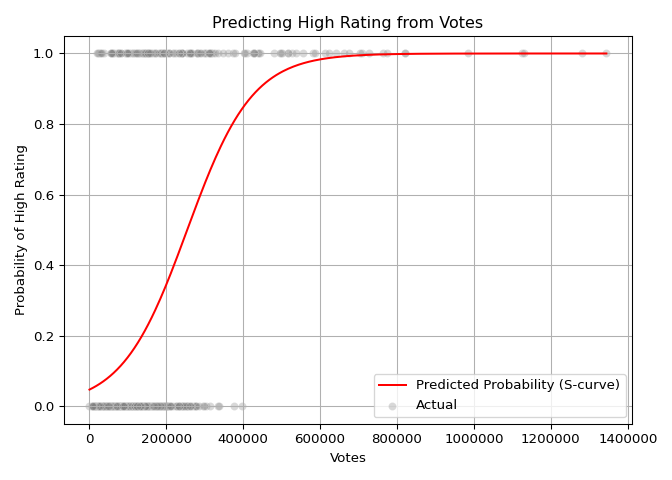

In [ ]:
# Plot predicted and actual energy against loudness
plt.plot(x_vals, probs, color='red', label='Predicted Probability (S-curve)')
sns.scatterplot(x=X.votes, y=y, alpha=0.3, color='gray', label='Actual')
plt.title('Predicting High Rating from Votes')
plt.xlabel('Votes')
plt.ylabel('Probability of High Rating')
plt.ticklabel_format(style='plain', axis='both');
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Logistic Regression with Multiple Predictors

In [ ]:
# Define predictors (runtime_in_minutes and votes) and 
# binary rating response (rating > 7 -> high rating)
X = imdb_movie_sample[['runtime_in_minutes', 'votes']]
y = (imdb_movie_sample['rating'] > 7).astype(int)

In [ ]:
# Fit the model
model = LogisticRegression()
model.fit(X, y)

LogisticRegression()

In [ ]:
# Predict probabilities
imdb_movie_sample['predicted_prob'] = model.predict_proba(X)[:, 1]

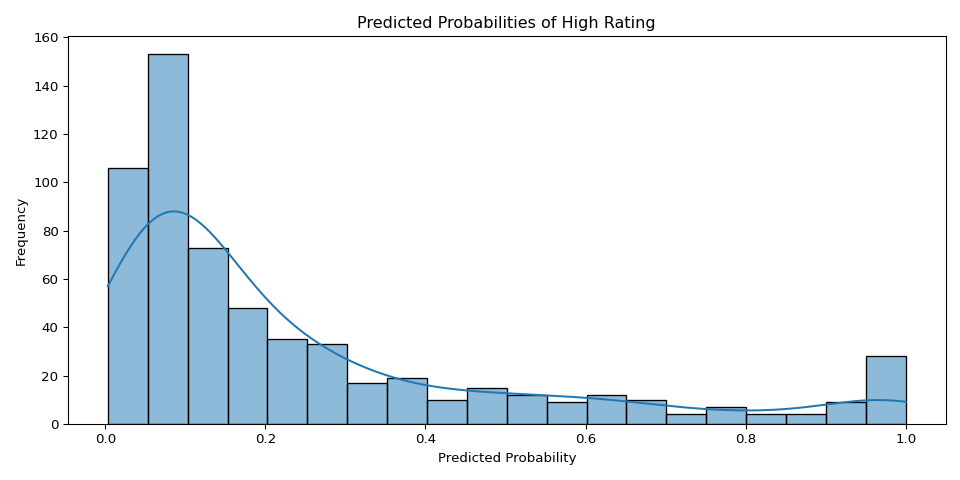

In [ ]:
# Plot the predicted probabilities
plt.figure(figsize=(10, 5))
sns.histplot(imdb_movie_sample['predicted_prob'], bins=20, kde=True)
plt.title('Predicted Probabilities of High Rating')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

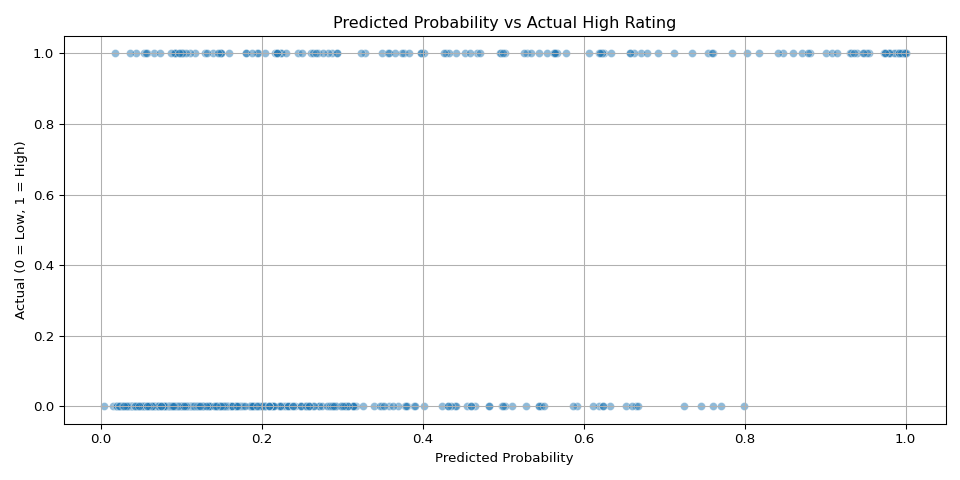

In [ ]:
# Scatter plot: predicted probability vs actual outcome
plt.figure(figsize=(10, 5))
sns.scatterplot(x=imdb_movie_sample['predicted_prob'], y=y, alpha=0.5)
plt.title('Predicted Probability vs Actual High Rating')
plt.xlabel('Predicted Probability')
plt.ylabel('Actual (0 = Low, 1 = High)')
plt.grid(True)
plt.tight_layout()
plt.show()

## Walkthrough 1.5: ANOVA

### One-way ANOVA

In [ ]:
from statsmodels.formula.api import ols

# Choose some genres to compare
genres = ['pop', 'rock', 'hip-hop', 'jazz']

In [ ]:
# Subset the data to focus only on these genres
spotify_sample_subset = spotify_sample[spotify_sample['track_genre'].isin(genres)]

In [ ]:
# Perform one-way ANOVA analyzing energy across different genres
model = ols('energy ~ C(track_genre)', data=spotify_sample_subset).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table

                     sum_sq             df            F       PR(>F)
C(track_genre) 0.6934067730   3.0000000000 9.1126797435 0.0000107804
Residual       5.2757481091 208.0000000000          NaN          NaN

### Boxplot across groups

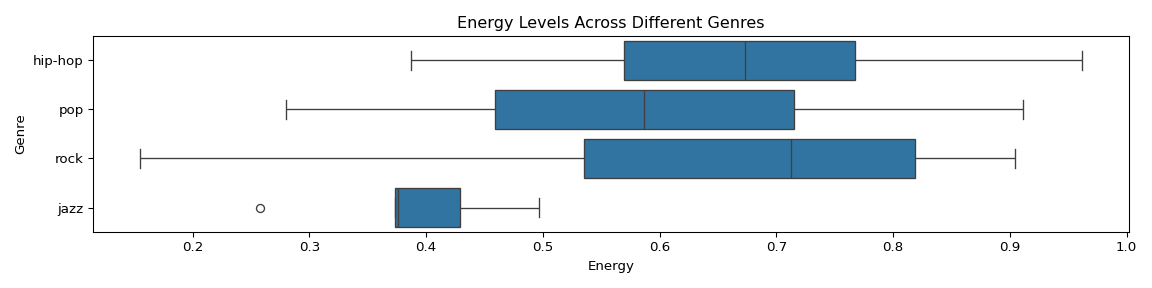

In [ ]:
# Boxplot for visualization
plt.figure(figsize=(12, 3))
sns.boxplot(y='track_genre', x='energy', data=spotify_sample_subset)
plt.title('Energy Levels Across Different Genres')
plt.xlabel('Energy')
plt.ylabel('Genre')
plt.tight_layout()
plt.show();

### Two-way ANOVA

In [ ]:
# Perform two-way ANOVA analyzing energy across genres and explicit content
model = ols('energy ~ C(track_genre) * C(explicit)', data=spotify_sample_subset).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table

                                 sum_sq             df            F  \
C(track_genre)             0.4174453902   3.0000000000 5.4333141883   
C(explicit)                0.0137309846   1.0000000000 0.5361521914   
C(track_genre):C(explicit) 0.0361559502   3.0000000000 0.4705924222   
Residual                   5.2500985604 205.0000000000          NaN   

                                 PR(>F)  
C(track_genre)             0.0050206062  
C(explicit)                0.4648680759  
C(track_genre):C(explicit) 0.6253051939  
Residual                            NaN  

### Boxplot across groups with color added

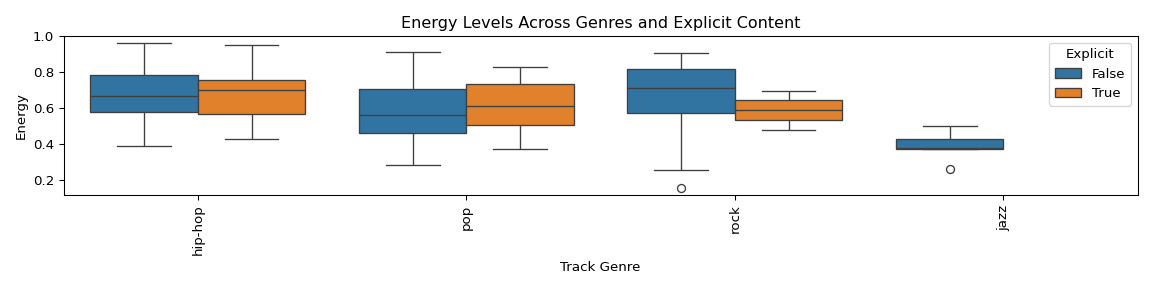

In [ ]:
# Boxplot for visualization
plt.figure(figsize=(12, 3))
sns.boxplot(x='track_genre', y='energy', hue='explicit', data=spotify_sample_subset)
plt.title('Energy Levels Across Genres and Explicit Content')
plt.xlabel('Track Genre')
plt.ylabel('Energy')
plt.xticks(rotation=90);
plt.legend(title='Explicit')
plt.tight_layout()
plt.show();

## Exercise 1.5: ANOVA

### One-way ANOVA

In [ ]:
# Choose some genres to compare ('Action', 'Crime', 'Horror', 'Romance')
movie_genres = ['Action', 'Crime', 'Horror', 'Romance']

# Subset the data to focus only on these genres
imdb_movie_sample_subset = imdb_movie_sample[imdb_movie_sample['genre'].isin(movie_genres)]

# Perform one-way ANOVA analyzing rating across different genres
model = ols('rating ~ C(genre)', data=imdb_movie_sample_subset).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table

                 sum_sq             df            F       PR(>F)
C(genre)  14.8232177340   3.0000000000 8.5042146836 0.0000176091
Residual 221.3665484998 381.0000000000          NaN          NaN

### Boxplot across groups

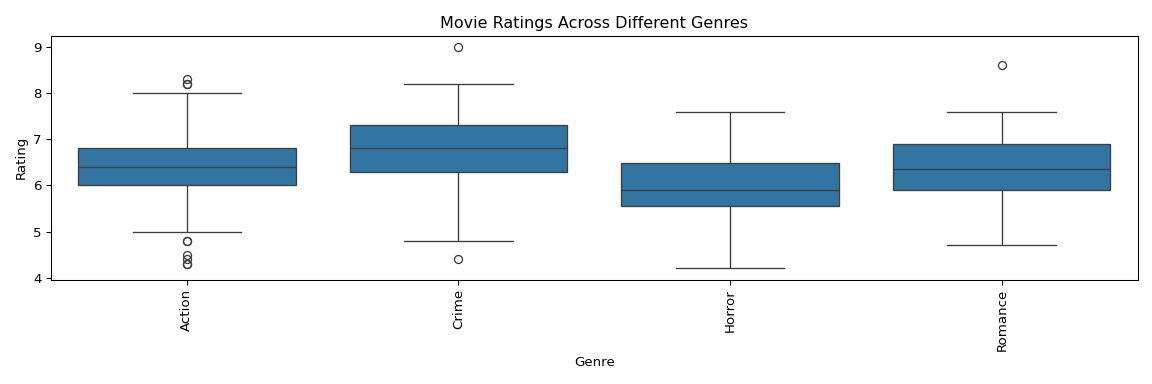

In [ ]:
# Boxplot for visualization
plt.figure(figsize=(12, 4))
sns.boxplot(x='genre', y='rating', data=imdb_movie_sample_subset)
plt.title('Movie Ratings Across Different Genres')
plt.xlabel('Genre')
plt.ylabel('Rating')
plt.xticks(rotation=90);
plt.tight_layout()
plt.show();

### Two-way ANOVA

In [ ]:
# Perform two-way ANOVA analyzing rating across genres and decades
model = ols('rating ~ C(genre) * C(decade)', data=imdb_movie_sample_subset).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table

                           sum_sq             df             F       PR(>F)
C(genre)            -0.0000000000   3.0000000000 -0.0000000000 1.0000000000
C(decade)           14.3118058509   6.0000000000  4.2736890848 0.0021612864
C(genre):C(decade)  26.4004381306  18.0000000000  2.6278366604 0.0008773155
Residual           202.6034736719 363.0000000000           NaN          NaN

### Boxplot across groups with color added

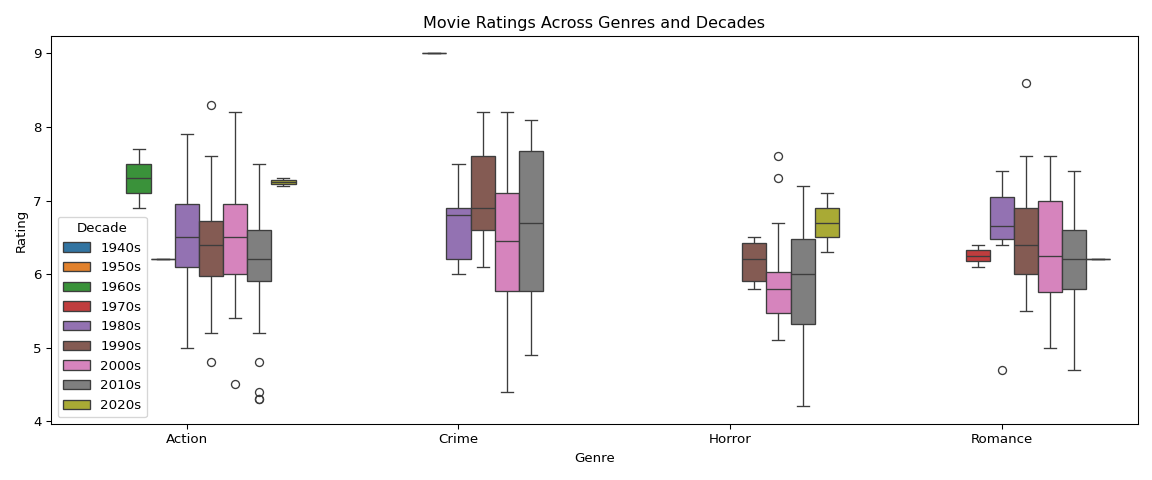

In [ ]:
# Some customization here to get the decades to appear in the appropriate order

# Define the ordered categories
decades = ['1940s', '1950s', '1960s', '1970s', '1980s', '1990s', 
           '2000s', '2010s', '2020s']

# Convert 'decade' column to a categorical type with ordered categories
imdb_movie_sample_subset['decade'] = pd.Categorical(
  imdb_movie_sample_subset['decade'], categories=decades, ordered=True)

# Boxplot for visualization
plt.figure(figsize=(12, 5))
sns.boxplot(x='genre', y='rating', hue='decade', data=imdb_movie_sample_subset)
plt.title('Movie Ratings Across Genres and Decades')
plt.xlabel('Genre')
plt.ylabel('Rating')
plt.legend(title='Decade')
plt.tight_layout()
plt.show();

# Week 2

## Walkthrough 2.1: Kruskal-Wallis and Mann-Whitney U Tests

### Kruskal-Wallis

In [ ]:
import scipy.stats as stats

# Perform Kruskal-Wallis Test on 'danceability' grouped by 'track_genre'
grouped_data = [group["danceability"].values 
    for name, group in spotify_sample.groupby("track_genre")]
stat, p_value = stats.kruskal(*grouped_data)
print(f"Kruskal-Wallis Test Statistic: {stat}")

Kruskal-Wallis Test Statistic: 716.1550864769308

P-value: 8.079896027452027e-106

### Mann-Whitney U

In [ ]:
# Perform Mann-Whitney U Test on 'energy' for pop versus rock
group1 = spotify_sample[spotify_sample["track_genre"] == "pop"]["energy"]
group2 = spotify_sample[spotify_sample["track_genre"] == "rock"]["energy"]
stat, p_value = stats.mannwhitneyu(group1, group2)
print(f"Mann-Whitney U Test Statistic: {stat}")

Mann-Whitney U Test Statistic: 1331.5

P-value: 0.006209251182150306

## Exercise 2.1: Kruskal-Wallis and Mann-Whitney U Tests

### Kruskal-Wallis

In [ ]:
# Perform Kruskal-Wallis Test on 'rating' grouped by 'decade'
grouped_data = [group["rating"].values 
                  for name, group in imdb_movie_sample.groupby("decade")]
stat, p_value = stats.kruskal(*grouped_data)
print(f"Kruskal-Wallis Test Statistic: {stat}")

Kruskal-Wallis Test Statistic: 36.74748438743329

P-value: 1.2807086053814844e-05

### Mann-Whitney U

In [ ]:
# Perform Mann-Whitney U Test on 'gross_in_dollars' for 1990s versus 2000s
group1 = imdb_movie_sample[imdb_movie_sample["decade"] == "1990s"]\
            ["gross_in_dollars"]
group2 = imdb_movie_sample[imdb_movie_sample["decade"] == "2000s"]\
            ["gross_in_dollars"]
stat, p_value = stats.mannwhitneyu(group1, group2)
print(f"Mann-Whitney U Test Statistic: {stat}")

Mann-Whitney U Test Statistic: 12435.0

P-value: 0.12806672731387908

## Walkthrough 2.2: Correlation and Regression Non-parametrics

### Spearman’s Rank Correlation

                    popularity   duration_ms  danceability        energy  \
popularity        1.0000000000 -0.0724404387  0.1297024598 -0.0007773904   
duration_ms      -0.0724404387  1.0000000000 -0.2516417129  0.0011752092   
danceability      0.1297024598 -0.2516417129  1.0000000000  0.0151953098   
energy           -0.0007773904  0.0011752092  0.0151953098  1.0000000000   
key              -0.0175740545  0.0282084234  0.0330479159  0.0150449450   
loudness          0.0799689147 -0.0913399124  0.1616557677  0.7053226222   
mode             -0.0368641083  0.0482483424 -0.1309432351 -0.0665196643   
speechiness       0.0671387433 -0.2193690157  0.2756320601  0.2648275802   
acousticness     -0.0400394686 -0.0480849082  0.0419876130 -0.5777585749   
instrumentalness -0.0423282818  0.1246080181 -0.1201208069 -0.0455340939   
liveness         -0.0149145060 -0.0472456203 -0.0944233712  0.1251138606   
valence          -0.0074381806 -0.1306374038  0.4077224299  0.3541404035   
tempo       

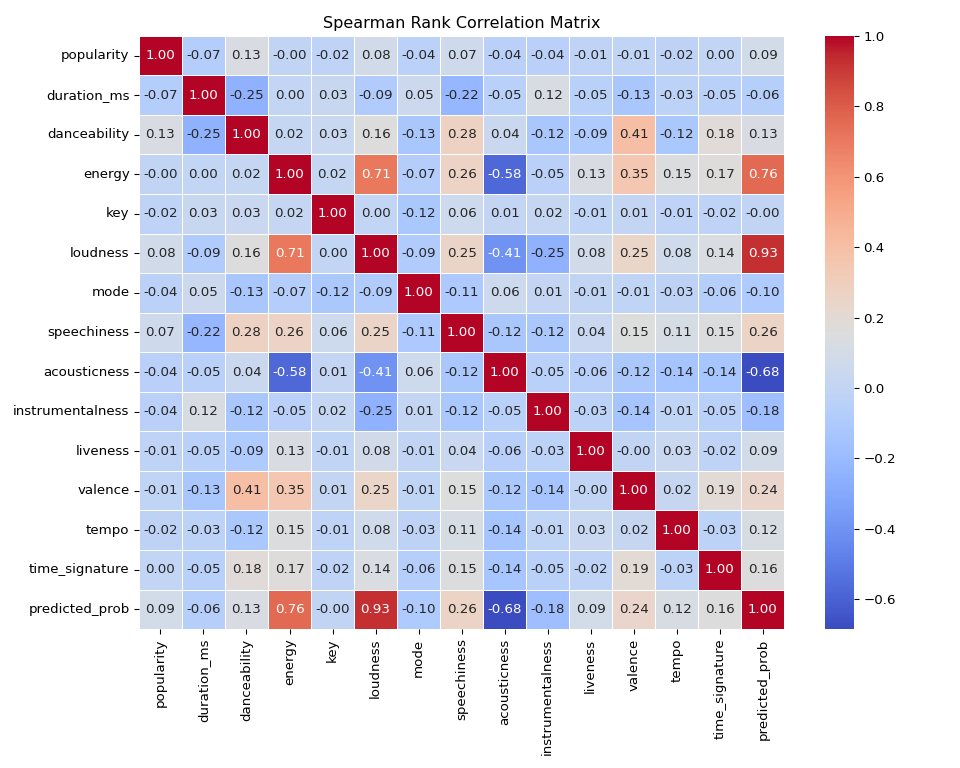

In [ ]:
from scipy.stats import spearmanr, kendalltau
from sklearn.linear_model import TheilSenRegressor

# Filter numeric columns
numeric_columns = spotify_sample.select_dtypes(include=[np.number])

# Calculate Spearman's rank correlation matrix
spearman_corr = numeric_columns.corr(method='spearman')
spearman_corr

### Kendall’s Tau Correlation

                    popularity   duration_ms  danceability        energy  \
popularity        1.0000000000 -0.0500288647  0.0899368767 -0.0010306163   
duration_ms      -0.0500288647  1.0000000000 -0.1717490767  0.0001842896   
danceability      0.0899368767 -0.1717490767  1.0000000000  0.0070009466   
energy           -0.0010306163  0.0001842896  0.0070009466  1.0000000000   
key              -0.0127214932  0.0195324074  0.0228618954  0.0105875160   
loudness          0.0551038867 -0.0623904849  0.1087390853  0.5169817359   
mode             -0.0312175162  0.0394054423 -0.1070393688 -0.0543668684   
speechiness       0.0459943084 -0.1489794306  0.1845596397  0.1772474640   
acousticness     -0.0277724233 -0.0320900699  0.0288220786 -0.4138117597   
instrumentalness -0.0309592887  0.0895078432 -0.0833483892 -0.0322857296   
liveness         -0.0103816765 -0.0310261181 -0.0621747819  0.0838049134   
valence          -0.0053665109 -0.0876258260  0.2775566448  0.2409262311   
tempo       

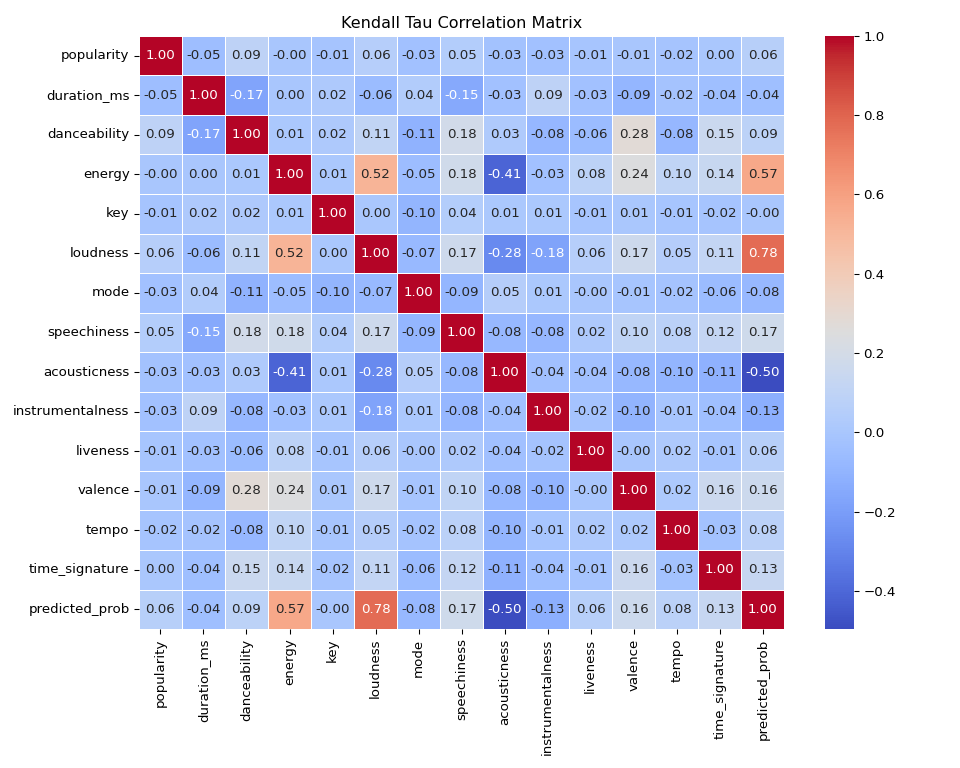

In [ ]:
# Calculate Kendall's tau correlation matrix
kendall_corr = numeric_columns.corr(method='kendall')
kendall_corr

### Theil-Sen Robust Regression

In [ ]:
# Theil-Sen robust regression for 'danceability' and 'energy' 
# predicting 'popularity'
X = numeric_columns[['danceability', 'energy']]
y = numeric_columns['popularity']
theil_sen = TheilSenRegressor()
theil_sen.fit(X, y)

TheilSenRegressor()

Intercept: 73.63327854599063

Coefficients: [ 2.84380283 -0.09904533]

## Exercise 2.2: Correlation and Regression Non-parametrics

### Spearman’s Rank Correlation

                            year  runtime_in_minutes        rating  \
year                1.0000000000       -0.1422072143 -0.1880401214   
runtime_in_minutes -0.1422072143        1.0000000000  0.4094107407   
rating             -0.1880401214        0.4094107407  1.0000000000   
votes               0.1730106500        0.2396250722  0.5362130540   
gross_in_dollars    0.0241271334       -0.0083110942 -0.0567188838   
predicted_prob      0.0390087506        0.6816700955  0.6137571524   

                          votes  gross_in_dollars  predicted_prob  
year               0.1730106500      0.0241271334    0.0390087506  
runtime_in_minutes 0.2396250722     -0.0083110942    0.6816700955  
rating             0.5362130540     -0.0567188838    0.6137571524  
votes              1.0000000000      0.0195568331    0.8418919222  
gross_in_dollars   0.0195568331      1.0000000000   -0.0021070400  
predicted_prob     0.8418919222     -0.0021070400    1.0000000000  

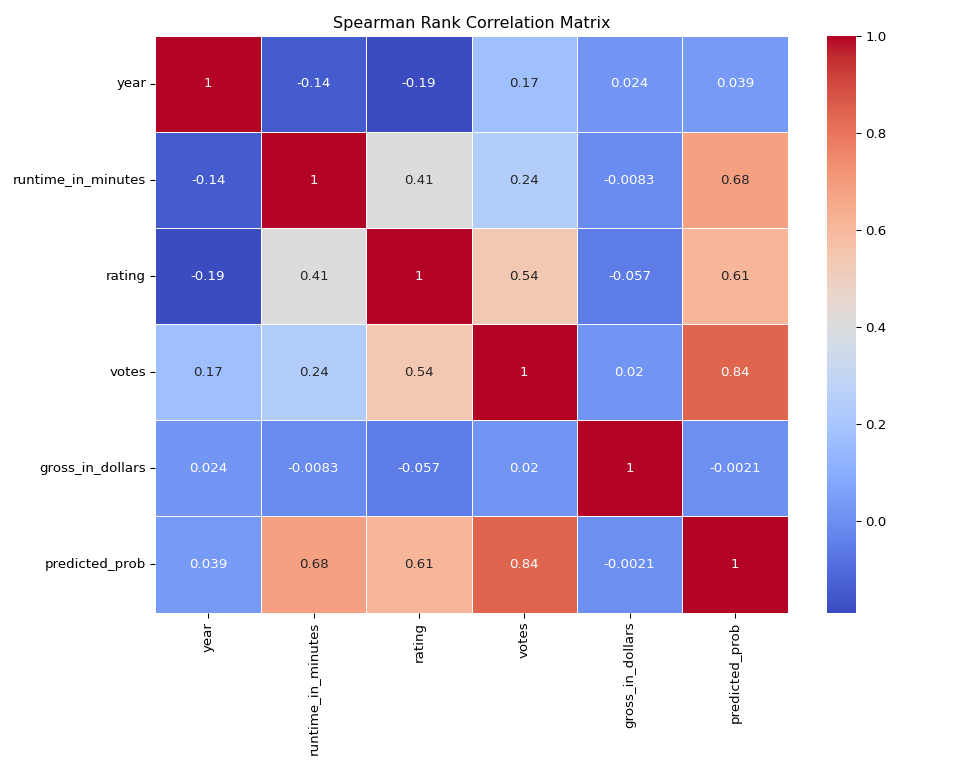

In [ ]:
# Filter numeric columns
numeric_columns = imdb_movie_sample.select_dtypes(include=[np.number])

# Calculate Spearman's rank correlation matrix
spearman_corr = numeric_columns.corr(method='spearman')
print(spearman_corr)

### Kendall’s Tau Correlation

                            year  runtime_in_minutes        rating  \
year                1.0000000000       -0.0964143570 -0.1295811859   
runtime_in_minutes -0.0964143570        1.0000000000  0.2902520549   
rating             -0.1295811859        0.2902520549  1.0000000000   
votes               0.1224500214        0.1631173097  0.3870859563   
gross_in_dollars    0.0159829184       -0.0053290090 -0.0389553716   
predicted_prob      0.0274032105        0.5037635231  0.4504528262   

                          votes  gross_in_dollars  predicted_prob  
year               0.1224500214      0.0159829184    0.0274032105  
runtime_in_minutes 0.1631173097     -0.0053290090    0.5037635231  
rating             0.3870859563     -0.0389553716    0.4504528262  
votes              1.0000000000      0.0127623254    0.6622481744  
gross_in_dollars   0.0127623254      1.0000000000   -0.0012681002  
predicted_prob     0.6622481744     -0.0012681002    1.0000000000  

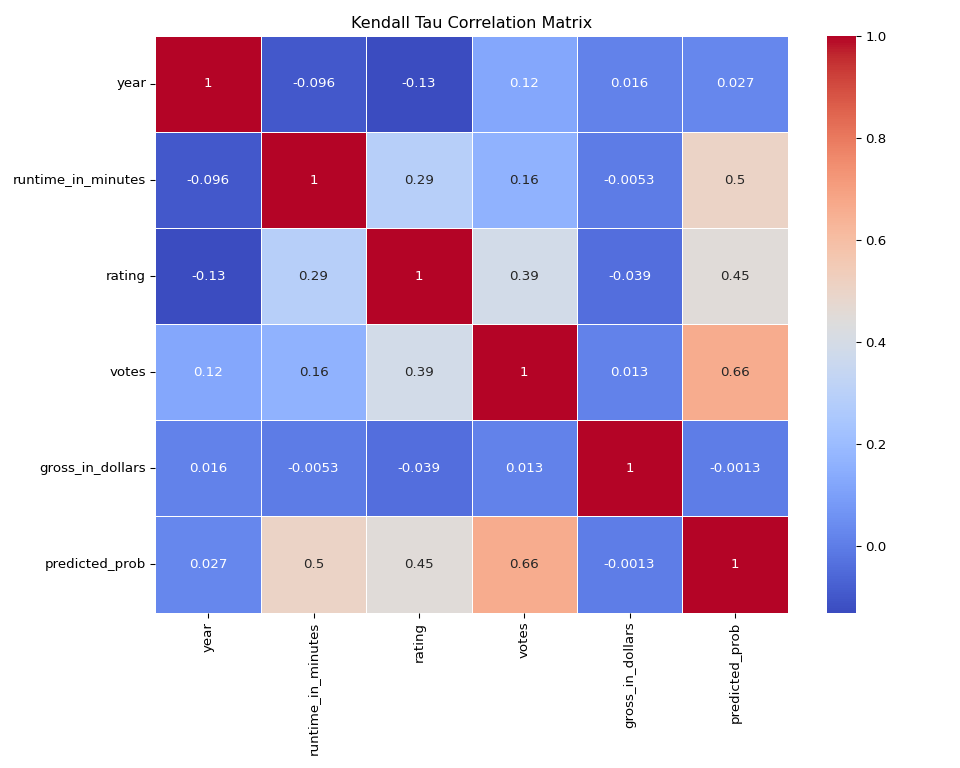

In [ ]:
# Calculate Kendall's tau correlation matrix
kendall_corr = numeric_columns.corr(method='kendall')
print(kendall_corr)

### Theil-Sen Robust Regression

In [ ]:
# Theil-Sen robust regression for 'votes' and 'runtime_in_minutes' predicting 'rating'
X = numeric_columns[['votes', 'runtime_in_minutes']]
y = numeric_columns['rating']
theil_sen = TheilSenRegressor()
theil_sen.fit(X, y)

TheilSenRegressor()

Intercept: 4.538976573348061

Coefficients: [0.0000037  0.01262686]

## Walkthrough 2.3: Bootstrapping

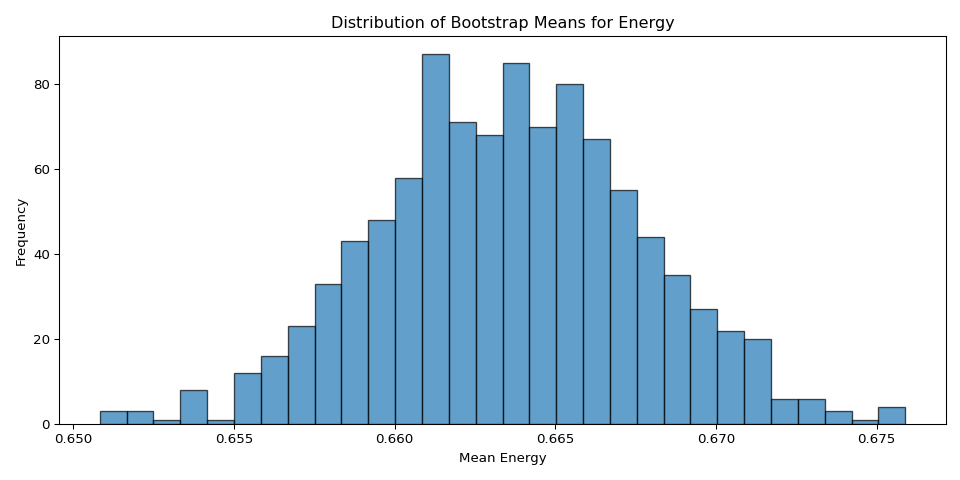

In [ ]:
# Function to perform bootstrapping
def bootstrap(data, n_bootstrap_samples=1000):
    bootstrap_samples = []
    for _ in range(n_bootstrap_samples):
        resample = data.sample(frac=1, replace=True)
        bootstrap_samples.append(resample.mean())
    return bootstrap_samples

# Perform bootstrapping on the 'energy' column
bootstrap_means = bootstrap(spotify_sample['energy'])

# Plot the distribution of bootstrap means
plt.figure(figsize=(10, 5))
plt.hist(bootstrap_means, bins=30, edgecolor='k', alpha=0.7)
plt.title('Distribution of Bootstrap Means for Energy')
plt.xlabel('Mean Energy')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show();

## Exercise 2.3: Bootstrapping

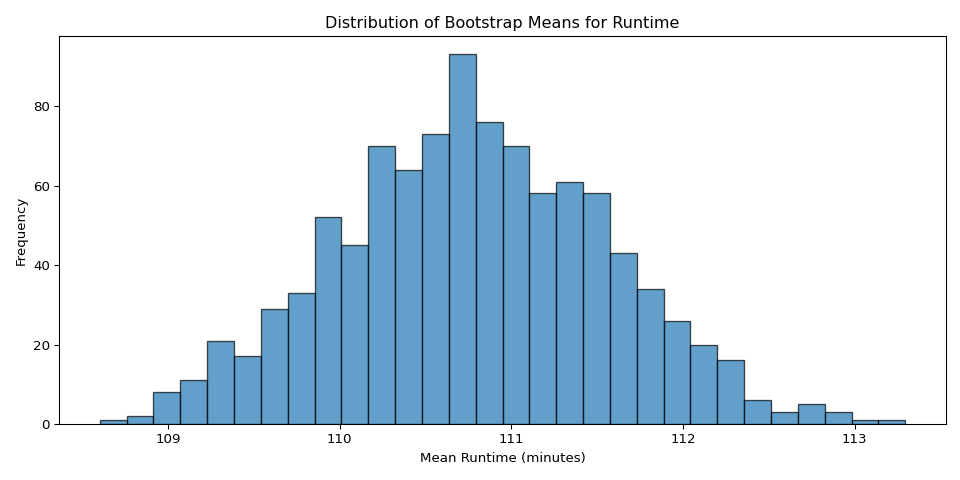

In [ ]:
# Perform bootstrapping on the 'runtime_in_minutes' column
# using the bootstrap function defined above
bootstrap_means = bootstrap(imdb_movie_sample['runtime_in_minutes'])

# Plot the distribution of bootstrap means
plt.figure(figsize=(10, 5))
plt.hist(bootstrap_means, bins=30, edgecolor='k', alpha=0.7)
plt.title('Distribution of Bootstrap Means for Runtime')
plt.xlabel('Mean Runtime (minutes)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show();

## Walkthrough 2.4: Confidence Intervals

95% Confidence Interval for Mean Energy: [0.6548814750494071, 0.6722282312252965]

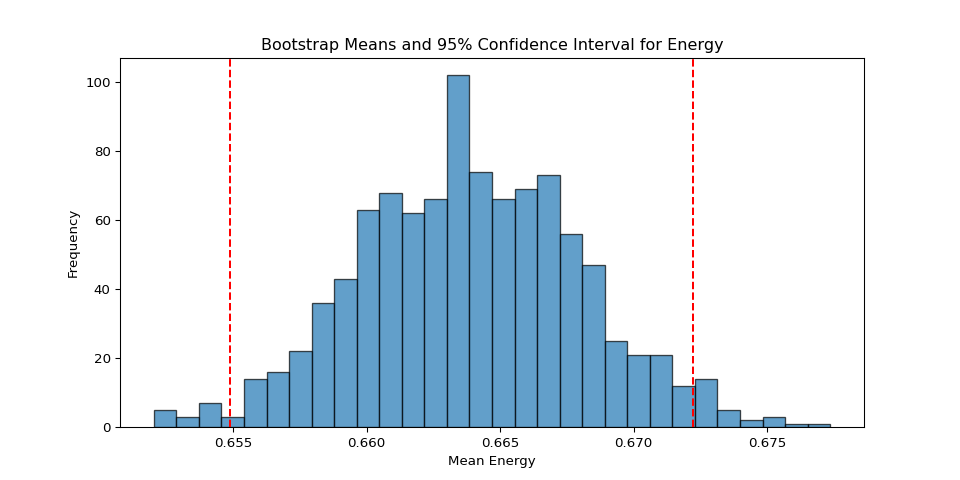

In [ ]:
# Function to calculate bootstrap confidence intervals
def bootstrap_confidence_interval(data, n_bootstrap_samples=1000, confidence_level=0.95):
    bootstrap_samples = []
    for _ in range(n_bootstrap_samples):
        resample = data.sample(frac=1, replace=True)
        bootstrap_samples.append(resample.mean())
    lower_bound = np.percentile(bootstrap_samples, (1 - confidence_level) / 2 * 100)
    upper_bound = np.percentile(bootstrap_samples, (1 + confidence_level) / 2 * 100)
    return lower_bound, upper_bound

# Calculate confidence intervals for the 'energy' column
lower, upper = bootstrap_confidence_interval(spotify_sample['energy'])
print(f"95% Confidence Interval for Mean Energy: [{lower}, {upper}]")

## Exercise 2.4: Confidence Intervals

95% Confidence Interval for Mean Rating: [6.422853618421053, 6.550497532894736]

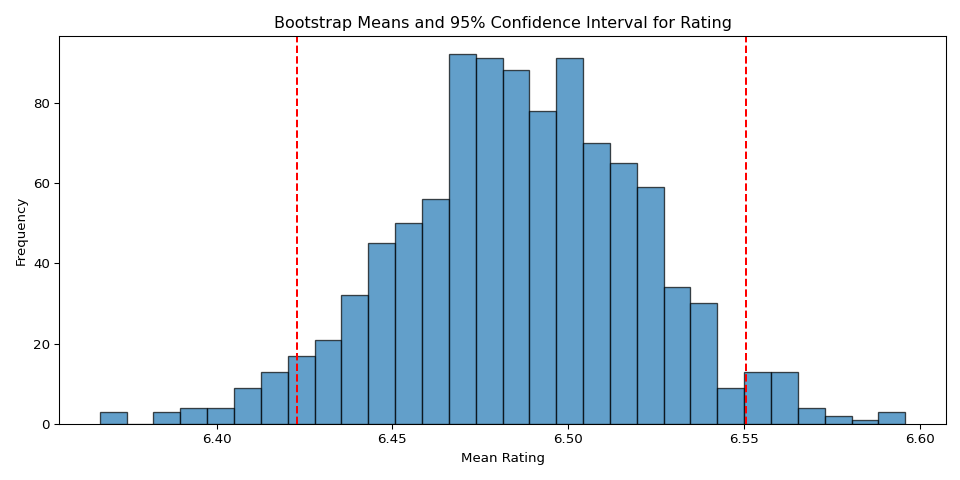

In [ ]:
# Calculate confidence intervals for the 'rating' column using the
# bootstrap_confidence_interval function defined above
lower, upper = bootstrap_confidence_interval(imdb_movie_sample['rating'])
print(f"95% Confidence Interval for Mean Rating: [{lower}, {upper}]")

## Walkthrough 2.5: Real-World Scenarios for Bootstrapping

**Music Industry Analytics**

*Objective*: Analyzing song popularity and estimating population mean
popularity.

*Scenario*: You are a data scientist for a movie production company.
Your role is to analyze movie ratings and predict the average rating of
movies produced. By using bootstrapping techniques, you aim to estimate
the mean movie rating and its variability to understand the unknown
population mean.

*Bootstrapping Applications*:

-   *Estimating Average Popularity*: Use bootstrapping to calculate the
    mean and confidence intervals of the popularity scores.
-   *Assessing Variability*: Determine the variability in the means of
    song popularity.

Bootstrapped Mean Popularity: 76.46716254940712

Bootstrapped Std Dev Popularity: 0.10777129940893569

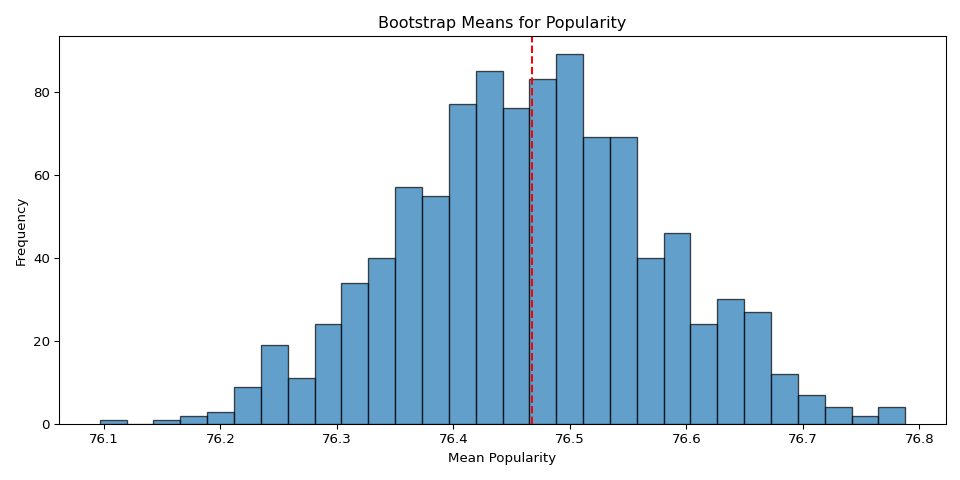

In [ ]:
# Calculate bootstrap statistics for the 'popularity' column

# Function to calculate bootstrap statistics
def bootstrap_statistics(data, n_bootstrap_samples=1000):
    bootstrap_means = []
    for _ in range(n_bootstrap_samples):
        resample = data.sample(frac=1, replace=True)
        bootstrap_means.append(resample.mean())
    return np.mean(bootstrap_means), np.std(bootstrap_means)

mean_popularity, std_popularity = bootstrap_statistics(spotify_sample['popularity'])
print(f"Bootstrapped Mean Popularity: {mean_popularity}")

## Exercise 2.5: Real-World Scenarios for Bootstrapping

**Film Industry Insights**

*Objective*: Evaluating movie gross revenue and estimating population
mean gross revenue.

*Scenario*: You are a data scientist for a movie production company.
Your role is to analyze movie gross revenue and predict the average
gross revenue of movies produced. By using bootstrapping techniques, you
aim to estimate the mean gross revenue and its variability to understand
the unknown population mean.

*Bootstrapping Applications*:

-   *Estimating Average Gross Revenue*: Use bootstrapping to calculate
    the mean and confidence intervals of movie gross revenue.
-   *Assessing Variability*: Determine the variability in the means of
    movie gross revenue.

Bootstrapped Mean Gross Revenue: 60585479.53255263

Bootstrapped Std Dev Gross Revenue: 291905.1650563464

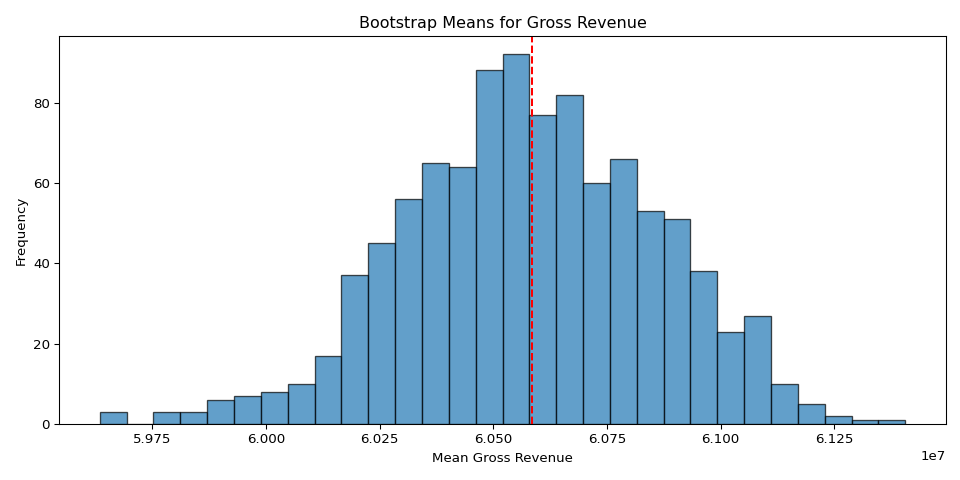

In [ ]:
# Calculate bootstrap statistics for the 'gross_in_dollars' column
# using the function called bootstrap_statistics defined above
mean_gross, std_gross = bootstrap_statistics(imdb_movie_sample['gross_in_dollars'])
print(f"Bootstrapped Mean Gross Revenue: {mean_gross}")